In [2]:
pip install arch


[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# =============================================================================
# NIFTY 50 — Risk Modelling & Stress Testing  (Phase 2)
# Requires: portfolio_weights.csv, returns_data.csv, mean_returns.csv, cov_matrix.csv
# Generated by portfolio_optimization_v2.py (Phase 1)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import norm, skew, kurtosis
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")
 
RF = 0.065

In [4]:
# │ CELL 2 — Load Phase 1 Outputs                                           │
# └─────────────────────────────────────────────────────────────────────────┘
 
weights_df   = pd.read_csv("portfolio_weights.csv",  index_col=0)
returns      = pd.read_csv("returns_data.csv",        index_col=0, parse_dates=True)
mean_returns = pd.read_csv("mean_returns.csv",        index_col=0, parse_dates=False).squeeze()
cov_matrix   = pd.read_csv("cov_matrix.csv",          index_col=0)
tickers = pd.read_csv("tickers.csv", header=None)[0].tolist()
 
tickers  = list(weights_df.index)
short    = [t.replace(".NS", "") for t in tickers]
port_names = list(weights_df.columns)
n        = len(tickers)
 
# Rebuild numpy arrays
mu    = mean_returns.values
Sigma = cov_matrix.values
 
# Rebuild portfolios dict: name → weight array
portfolios = {col: weights_df[col].values for col in port_names}
 
print(f"✓ Loaded {n} tickers, {len(returns)} trading days, {len(portfolios)} portfolios")
print(f"  Portfolios: {port_names}")
 

✓ Loaded 15 tickers, 741 trading days, 8 portfolios
  Portfolios: ['Markowitz (Unconstrained)', 'Markowitz 30% cap', 'Markowitz 20% cap', 'Sector 40% cap', 'Target Return 15%', 'Risk Parity', 'Black-Litterman', 'BL + 30% cap']


In [5]:
# =============================================================================
# PHASE 1 — HISTORICAL RISK ANALYSIS
# Goal: understand historical risk behaviour of each portfolio
# =============================================================================
 
 
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 3 — Portfolio Return Series                                        │
# │ Compute daily return series for each portfolio.                        │
# │ port_returns[col] = daily P&L of that allocation.                      │
# └─────────────────────────────────────────────────────────────────────────┘
 
port_returns = pd.DataFrame(
    {name: returns.values @ w for name, w in portfolios.items()},
    index=returns.index
)
 
print("── Daily return sample (last 5 rows) ──")
print(port_returns.tail())

# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 4 — Annualised Volatility per Portfolio                            │
# └─────────────────────────────────────────────────────────────────────────┘
 
ann_vol = port_returns.std() * np.sqrt(252)
 
print("── Annualised Volatility ──")
print(ann_vol.sort_values().round(4).to_string())

── Daily return sample (last 5 rows) ──
            Markowitz (Unconstrained)  Markowitz 30% cap  Markowitz 20% cap  \
Date                                                                          
2026-06-05                  -0.008469          -0.002079           0.000325   
2026-06-08                   0.005980          -0.002383          -0.006155   
2026-06-09                  -0.000641           0.005854           0.006235   
2026-06-10                  -0.009258          -0.003161          -0.001240   
2026-06-11                   0.001681          -0.000481           0.000548   

            Sector 40% cap  Target Return 15%  Risk Parity  Black-Litterman  \
Date                                                                          
2026-06-05       -0.003936           0.001029     0.000414         0.003643   
2026-06-08        0.000304          -0.002711    -0.008508        -0.016599   
2026-06-09        0.004764           0.004541     0.005988         0.008645   
2026-06-10 

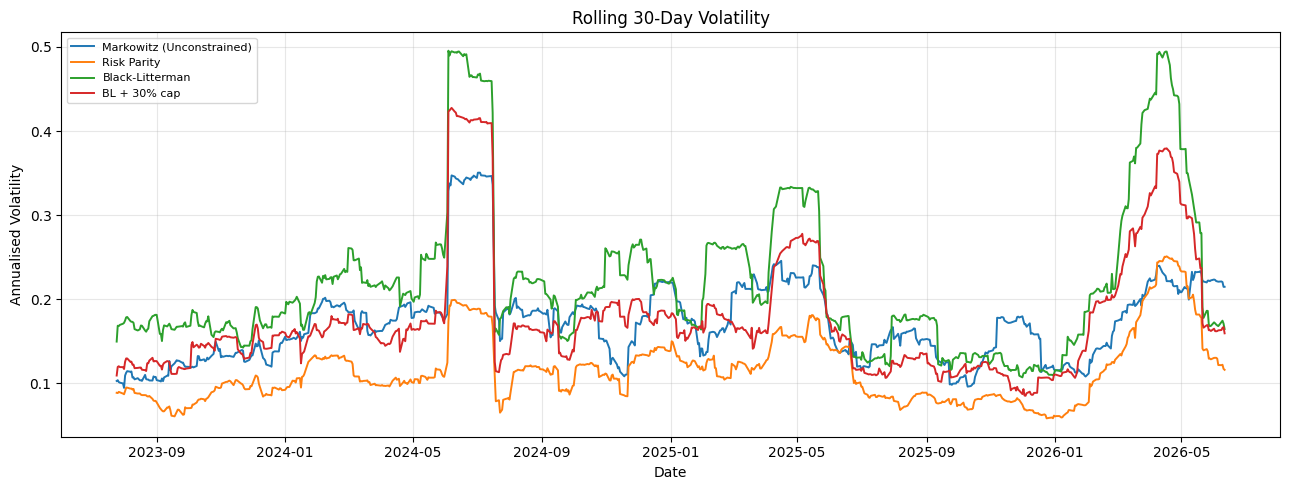

In [6]:
# │ CELL 5 — Rolling 30-Day Volatility                                      │
# │ Shows how risk changes over time — useful for spotting regime shifts.  │
# └─────────────────────────────────────────────────────────────────────────┘
 
rolling_vol = port_returns.rolling(30).std() * np.sqrt(252)
 
# Plot selected portfolios to keep it readable
plot_ports = ["Markowitz (Unconstrained)", "Risk Parity",
              "Black-Litterman", "BL + 30% cap"]
 
plt.figure(figsize=(13, 5))
for p in plot_ports:
    plt.plot(rolling_vol.index, rolling_vol[p], label=p, lw=1.4)
plt.xlabel("Date"); plt.ylabel("Annualised Volatility")
plt.title("Rolling 30-Day Volatility")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
 

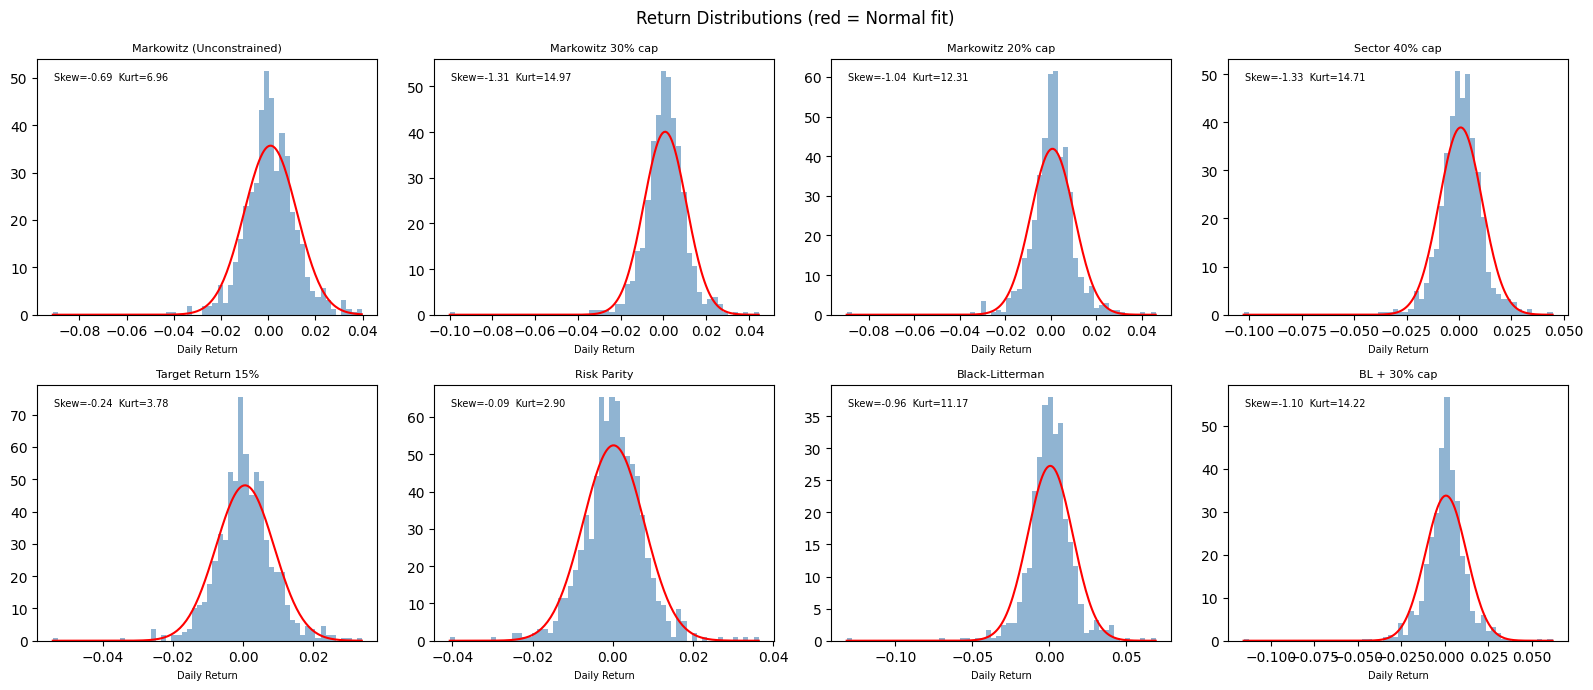

In [7]:
# │ CELL 6 — Return Distribution Plots                                      │
# │ Histogram + normal overlay to visualise fat tails.                     │
# └─────────────────────────────────────────────────────────────────────────┘
 
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
 
for i, (name, w) in enumerate(portfolios.items()):
    ax   = axes[i]
    data = port_returns[name].dropna()
    ax.hist(data, bins=60, density=True, color="steelblue", alpha=0.6, edgecolor="none")
    # Normal overlay
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, norm.pdf(x, data.mean(), data.std()), color="red", lw=1.5)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("Daily Return", fontsize=7)
    sk = skew(data); ku = kurtosis(data)
    ax.text(0.05, 0.92, f"Skew={sk:.2f}  Kurt={ku:.2f}",
            transform=ax.transAxes, fontsize=7)
 
plt.suptitle("Return Distributions (red = Normal fit)", fontsize=12)
plt.tight_layout(); plt.show()

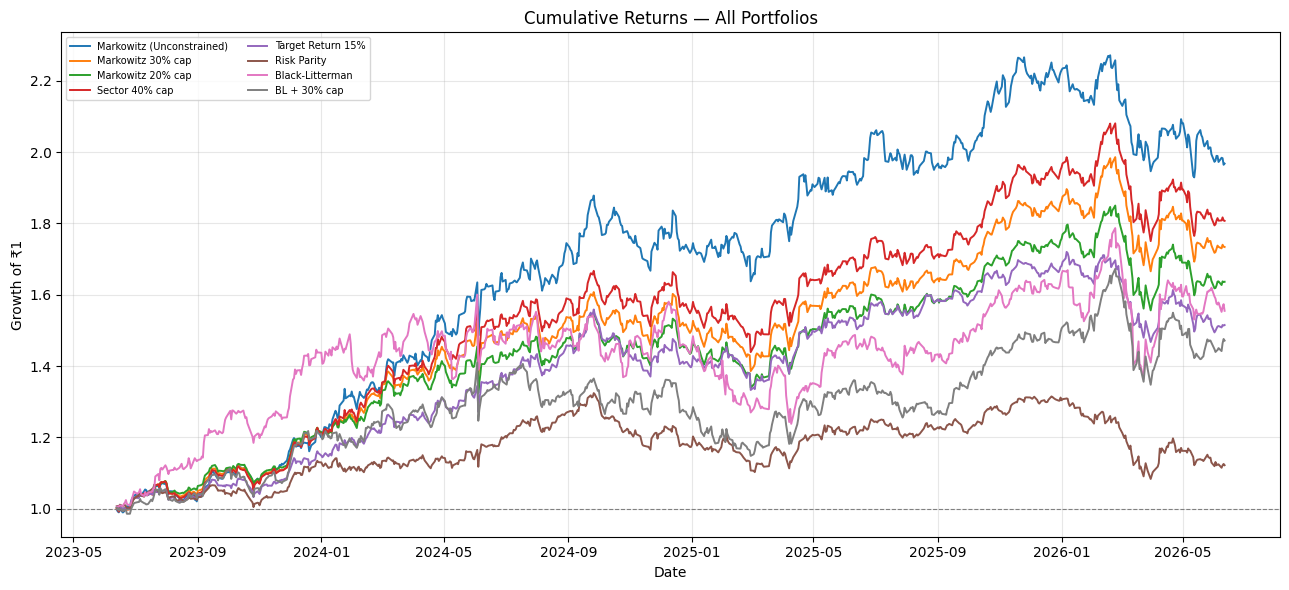

In [8]:
# │ CELL 7 — Cumulative Returns                                             │
# └─────────────────────────────────────────────────────────────────────────┘
 
cum_returns = (1 + port_returns).cumprod()
 
plt.figure(figsize=(13, 6))
for name in port_names:
    plt.plot(cum_returns.index, cum_returns[name], label=name, lw=1.4)
plt.axhline(1.0, color="gray", linestyle="--", lw=0.8)
plt.xlabel("Date"); plt.ylabel("Growth of ₹1")
plt.title("Cumulative Returns — All Portfolios")
plt.legend(fontsize=7, ncol=2); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [9]:
# PHASE 2 — MONTE CARLO PORTFOLIO SIMULATION
# Goal: quantify future uncertainty over a 1-year horizon
# =============================================================================
 
 
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 8 — MC Simulation Engine                                           │
# │ Simulate 10,000 future 1-year paths for each portfolio.               │
# │ Each path = 252 daily returns drawn from multivariate normal.         │
# └─────────────────────────────────────────────────────────────────────────┘
 
N_SIMS    = 10_000
N_DAYS    = 252
INITIAL   = 1_000_000   # ₹10 lakh starting value
 
# Daily parameters
mu_daily    = mean_returns.values / 252
cov_daily   = cov_matrix.values   / 252
 
# Store terminal values for each portfolio
terminal_values = {}
all_paths       = {}    # store full paths for selected portfolios
 
print("Simulating paths...")
for name, w in portfolios.items():
    port_mu_d  = w @ mu_daily
    port_var_d = w @ cov_daily @ w
    port_std_d = np.sqrt(port_var_d)
 
    # Simulate using GBM: daily return ~ N(mu_d, sigma_d)
    daily_sim  = np.random.normal(port_mu_d, port_std_d, (N_SIMS, N_DAYS))
    paths      = INITIAL * np.cumprod(1 + daily_sim, axis=1)
 
    terminal_values[name] = paths[:, -1]
    all_paths[name]       = paths
    print(f"  ✓ {name}")
 
print("Done.")

Simulating paths...
  ✓ Markowitz (Unconstrained)
  ✓ Markowitz 30% cap
  ✓ Markowitz 20% cap
  ✓ Sector 40% cap
  ✓ Target Return 15%
  ✓ Risk Parity
  ✓ Black-Litterman
  ✓ BL + 30% cap
Done.


In [10]:
# │ CELL 9 — MC Results: Expected Value, Prob of Loss, Percentiles         │
# └─────────────────────────────────────────────────────────────────────────┘
 
mc_results = []
for name, tv in terminal_values.items():
    mc_results.append({
        "Portfolio":          name,
        "Expected Value (₹)": f"₹{np.mean(tv):,.0f}",
        "Prob of Loss %":     round((tv < INITIAL).mean() * 100, 1),
        "5th Pct (₹)":        f"₹{np.percentile(tv, 5):,.0f}",
        "95th Pct (₹)":       f"₹{np.percentile(tv, 95):,.0f}",
        "Median (₹)":         f"₹{np.median(tv):,.0f}",
    })
 
mc_df = pd.DataFrame(mc_results)
print(f"\nInitial investment: ₹{INITIAL:,}")
print(mc_df.to_string(index=False))
 


Initial investment: ₹1,000,000
                Portfolio Expected Value (₹)  Prob of Loss % 5th Pct (₹) 95th Pct (₹) Median (₹)
Markowitz (Unconstrained)         ₹1,282,349             9.5    ₹943,728   ₹1,694,892 ₹1,263,319
        Markowitz 30% cap         ₹1,220,661            11.6    ₹933,637   ₹1,560,603 ₹1,204,660
        Markowitz 20% cap         ₹1,195,769            13.7    ₹916,717   ₹1,519,524 ₹1,182,283
           Sector 40% cap         ₹1,240,564            11.4    ₹936,237   ₹1,609,044 ₹1,224,936
        Target Return 15%         ₹1,160,532            14.3    ₹925,257   ₹1,424,637 ₹1,152,127
              Risk Parity         ₹1,046,033            38.0    ₹852,338   ₹1,265,893 ₹1,038,405
          Black-Litterman         ₹1,195,586            26.0    ₹795,901   ₹1,711,094 ₹1,163,780
             BL + 30% cap         ₹1,163,840            23.6    ₹840,972   ₹1,558,872 ₹1,142,815


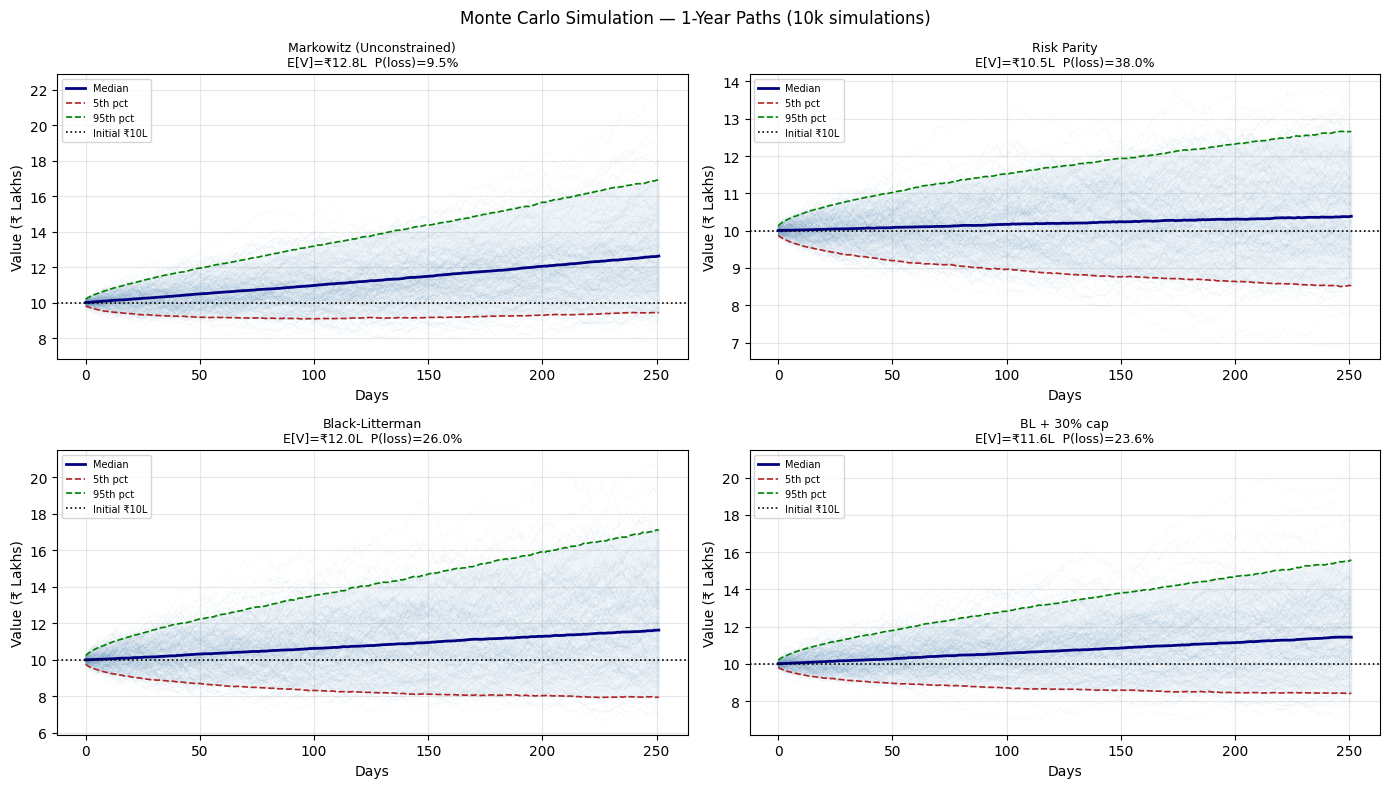

In [11]:
# │ CELL 10 — MC Path Plots (4 key portfolios)                              │
# └─────────────────────────────────────────────────────────────────────────┘
 
plot_ports = ["Markowitz (Unconstrained)", "Risk Parity",
              "Black-Litterman", "BL + 30% cap"]
 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
 
for i, name in enumerate(plot_ports):
    ax    = axes[i]
    paths = all_paths[name]
    days  = np.arange(N_DAYS)
 
    # 200 faint sample paths
    for j in np.random.choice(N_SIMS, 200, replace=False):
        ax.plot(days, paths[j] / 1e5, color="steelblue", alpha=0.05, lw=0.5)
 
    # Percentile bands
    p5  = np.percentile(paths, 5,  axis=0)
    p50 = np.percentile(paths, 50, axis=0)
    p95 = np.percentile(paths, 95, axis=0)
 
    ax.plot(days, p50 / 1e5, color="navy",      lw=2,   label="Median")
    ax.plot(days, p5  / 1e5, color="firebrick", lw=1.2, linestyle="--", label="5th pct")
    ax.plot(days, p95 / 1e5, color="green",     lw=1.2, linestyle="--", label="95th pct")
    ax.fill_between(days, p5/1e5, p95/1e5, alpha=0.08, color="steelblue")
    ax.axhline(INITIAL / 1e5, color="black", lw=1.2, linestyle=":", label="Initial ₹10L")
 
    tv = terminal_values[name]
    ax.set_title(f"{name}\nE[V]=₹{np.mean(tv)/1e5:.1f}L  P(loss)={((tv<INITIAL).mean()*100):.1f}%",
                 fontsize=9)
    ax.set_xlabel("Days"); ax.set_ylabel("Value (₹ Lakhs)")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
 
plt.suptitle("Monte Carlo Simulation — 1-Year Paths (10k simulations)", fontsize=12)
plt.tight_layout(); plt.show()

In [12]:
# PHASE 3 — STRESS TESTING
# Goal: test how portfolios behave during extreme market events
# =============================================================================

# CELL 11 — Historical Stress: Fetch Crisis Prices                        │
# │                                                                         │
# │ returns_data.csv only covers 3 years — 2020 and 2022 fall outside.    │
# │ Fix: fetch a 6-year price history directly here via yfinance.          │
# │ This is independent of Phase 1 and adds no re-run burden.             │
# └─────────────────────────────────────────────────────────────────────────┘
 
import yfinance as yf
 
print("Fetching 6-year price history for historical stress tests...")
prices_hist = yf.download(tickers, start="2019-01-01", end="2024-12-31",
                           auto_adjust=True, progress=False)["Close"]
prices_hist = prices_hist.dropna(how="all")
prices_hist = prices_hist[tickers]   # enforce column order
print(f"✓ {prices_hist.shape[0]} trading days × {prices_hist.shape[1]} stocks")
print(f"  Date range: {prices_hist.index[0].date()} → {prices_hist.index[-1].date()}")
 
def historical_scenario(start, end, label):
    """
    Compute actual stock returns over a crisis period using fetched prices.
    Returns (per-stock return vector, portfolio loss dict).
    """
    try:
        window = prices_hist.loc[start:end]
        if len(window) < 2:
            print(f"  ⚠ {label}: no data in {start}→{end}")
            return None
        stock_returns = window.iloc[-1] / window.iloc[0] - 1
        # align to tickers order
        stock_returns = stock_returns.reindex(tickers)
        result = {name: round((w @ stock_returns.values) * 100, 2)
                  for name, w in portfolios.items()}
        print(f"  ✓ {label}: {len(window)} trading days loaded")
        return stock_returns, result
    except Exception as e:
        print(f"  ⚠ {label}: {e}")
        return None
 
# ── Scenario 1: COVID Crash ───────────────────────────────────────────────
covid = historical_scenario("2020-02-20", "2020-03-23", "COVID Crash")
 
if covid:
    covid_stock_ret, covid_port_loss = covid
    print("\n── Scenario 1: COVID Crash (Feb 20 → Mar 23 2020) ──")
    print("\n  Stock returns during crash:")
    print(pd.Series(covid_stock_ret.values * 100, index=short).sort_values().round(2).to_string())
    print("\n  Portfolio losses (ranked most resilient → worst):")
    for name, loss in sorted(covid_port_loss.items(), key=lambda x: x[1], reverse=True):
        bar = "█" * int(abs(loss) / 2)
        print(f"  {name:<32} {loss:>7.2f}%  {bar}")
 

Fetching 6-year price history for historical stress tests...
✓ 1480 trading days × 15 stocks
  Date range: 2019-01-01 → 2024-12-30
  ✓ COVID Crash: 21 trading days loaded

── Scenario 1: COVID Crash (Feb 20 → Mar 23 2020) ──

  Stock returns during crash:
AXISBANK     -58.53
ICICIBANK    -48.08
SBIN         -44.58
LT           -43.46
RELIANCE     -40.51
TITAN        -39.45
MARUTI       -37.55
HDFCBANK     -36.61
KOTAKBANK    -34.86
INFY         -33.95
ITC          -25.62
BHARTIARTL   -25.34
TCS          -22.02
ASIANPAINT   -18.34
HINDUNILVR   -16.84

  Portfolio losses (ranked most resilient → worst):
  Markowitz (Unconstrained)         -30.64%  ███████████████
  Risk Parity                       -33.82%  ████████████████
  Target Return 15%                 -33.99%  ████████████████
  Sector 40% cap                    -36.44%  ██████████████████
  Markowitz 30% cap                 -38.21%  ███████████████████
  Markowitz 20% cap                 -39.94%  ███████████████████
  Black-Litt

In [13]:
# │ CELL 12 — Stress Scenario 2: Rate Hike Cycle (Historical Replay)        │
# │ Period: Jan 2022 → Oct 2022                                             │
# │ RBI + global rate hikes → growth stocks fell, financials mixed         │
# └─────────────────────────────────────────────────────────────────────────┘
 
rate = historical_scenario("2022-01-01", "2022-10-31", "Rate Hike 2022")
 
if rate:
    rate_stock_ret, rate_port_loss = rate
    print("── Scenario 2: Rate Hike Cycle (Jan → Oct 2022) ──")
    print("  Stock returns during period:")
    print(pd.Series(rate_stock_ret.values * 100, index=short).sort_values().round(2).to_string())
    print("  Portfolio losses (ranked best to worst):")
    for name, loss in sorted(rate_port_loss.items(), key=lambda x: x[1], reverse=True):
        bar = "█" * int(abs(loss) / 2)
        print(f"  {name:<32} {loss:>7.2f}%  {bar}")

  ✓ Rate Hike 2022: 205 trading days loaded
── Scenario 2: Rate Hike Cycle (Jan → Oct 2022) ──
  Stock returns during period:
INFY         -17.25
TCS          -15.21
ASIANPAINT    -8.54
HDFCBANK      -0.37
KOTAKBANK      4.31
RELIANCE       6.41
LT             6.56
HINDUNILVR     8.97
TITAN          9.80
ICICIBANK     19.54
BHARTIARTL    20.89
SBIN          23.78
MARUTI        27.46
AXISBANK      30.31
ITC           66.95
  Portfolio losses (ranked best to worst):
  Markowitz (Unconstrained)          20.80%  ██████████
  Sector 40% cap                     19.23%  █████████
  BL + 30% cap                       18.62%  █████████
  Markowitz 30% cap                  18.50%  █████████
  Markowitz 20% cap                  17.46%  ████████
  Target Return 15%                  17.23%  ████████
  Risk Parity                        12.67%  ██████
  Black-Litterman                     9.99%  ████


In [14]:
# │ CELL 13 — Stress Scenario 3: Financial Sector Crisis (Hypothetical)     │
# │ Banking -30%, NBFC-proxy (KOTAKBANK) -25%, others 0%                  │
# └─────────────────────────────────────────────────────────────────────────┘
 
SECTORS = {
    "Finance":   ["AXISBANK.NS","HDFCBANK.NS","ICICIBANK.NS","KOTAKBANK.NS","SBIN.NS"],
    "IT":        ["INFY.NS","TCS.NS"],
    "Consumer":  ["ASIANPAINT.NS","HINDUNILVR.NS","ITC.NS","TITAN.NS"],
    "Auto":      ["MARUTI.NS"],
    "Energy":    ["RELIANCE.NS"],
    "Telecom":   ["BHARTIARTL.NS"],
    "Industrial":["LT.NS"],
}
 
fin_shock_map = {
    "HDFCBANK.NS":  -0.30,
    "ICICIBANK.NS": -0.30,
    "SBIN.NS":      -0.30,
    "AXISBANK.NS":  -0.30,
    "KOTAKBANK.NS": -0.25,   # NBFC proxy
}
 
fin_shocks = np.zeros(n)
for t, shock in fin_shock_map.items():
    if t in tickers:
        fin_shocks[tickers.index(t)] = shock
 
print("── Scenario 3: Financial Sector Crisis (Hypothetical) ──")
print("  Applied shocks:")
for t, s in fin_shock_map.items():
    print(f"    {t.replace('.NS',''):<16} {s*100:.0f}%")
 
fin_losses = {}
for name, w in portfolios.items():
    loss = w @ fin_shocks
    fin_losses[name] = round(loss * 100, 2)
 
    # Risk contribution by sector
    sector_contrib = {}
    for sector, members in SECTORS.items():
        idx = [tickers.index(t) for t in members if t in tickers]
        sector_contrib[sector] = round((w[idx] @ fin_shocks[idx]) * 100, 2)
 
print("  Portfolio losses + sector contribution:")
print(f"  {'Portfolio':<32} {'Total':>8}  Finance  IT  Consumer  Other")
print("-"*75)
for name, w in portfolios.items():
    total = w @ fin_shocks * 100
    fin_c = sum(w[tickers.index(t)] * fin_shock_map[t]
                for t in fin_shock_map if t in tickers) * 100
    print(f"  {name:<32} {total:>7.2f}%  {fin_c:>6.2f}%")
 

── Scenario 3: Financial Sector Crisis (Hypothetical) ──
  Applied shocks:
    HDFCBANK         -30%
    ICICIBANK        -30%
    SBIN             -30%
    AXISBANK         -30%
    KOTAKBANK        -25%
  Portfolio losses + sector contribution:
  Portfolio                           Total  Finance  IT  Consumer  Other
---------------------------------------------------------------------------
  Markowitz (Unconstrained)          -6.79%   -6.79%
  Markowitz 30% cap                 -11.93%  -11.93%
  Markowitz 20% cap                 -11.71%  -11.71%
  Sector 40% cap                    -11.30%  -11.30%
  Target Return 15%                  -9.18%   -9.18%
  Risk Parity                        -8.99%   -8.99%
  Black-Litterman                    -4.92%   -4.92%
  BL + 30% cap                      -20.50%  -20.50%


In [15]:
# │ CELL 13b — Stress Scenario 4: Volatility Regime Shift                  │
# │ Not a return shock — instead scale volatility by 2.5×                 │
# │ Re-run MC and compute VaR, CVaR, P(loss), P(drawdown > 20%)           │
# └─────────────────────────────────────────────────────────────────────────┘
 
VOL_SCALE = 2.5
N_DAYS_S4 = 252
cov_shocked = cov_matrix.values * (VOL_SCALE ** 2) / 252
mu_daily    = mean_returns.values / 252
 
print(f"── Scenario 4: Volatility Regime Shift (σ × {VOL_SCALE}) ──")
print(f"  {'Portfolio':<32} {'VaR 95%':>9}  {'CVaR 95%':>10}  {'P(Loss)%':>10}  {'P(DD>20%)':>11}")
print("-"*78)
 
vol_shock_results = {}
for name, w in portfolios.items():
    port_mu_d  = w @ mu_daily
    port_std_d = np.sqrt(w @ cov_shocked @ w)
 
    sims      = np.random.normal(port_mu_d, port_std_d, (N_SIMS, N_DAYS_S4))
    paths     = np.cumprod(1 + sims, axis=1)
    terminal  = paths[:, -1] - 1
 
    var_s4    = -np.percentile(terminal, 5)
    cvar_s4   = -terminal[terminal <= -var_s4].mean()
    p_loss    = (terminal < 0).mean() * 100
    p_dd20    = (paths.min(axis=1) < 0.80).mean() * 100   # ever drops below 80%
 
    vol_shock_results[name] = {
        "VaR 95%": round(var_s4*100, 2),
        "CVaR 95%": round(cvar_s4*100, 2),
        "P(Loss)%": round(p_loss, 1),
        "P(DD>20%)": round(p_dd20, 1),
    }
    print(f"  {name:<32} {var_s4*100:>8.2f}%  {cvar_s4*100:>9.2f}%  "
          f"{p_loss:>9.1f}%  {p_dd20:>10.1f}%")

── Scenario 4: Volatility Regime Shift (σ × 2.5) ──
  Portfolio                          VaR 95%    CVaR 95%    P(Loss)%    P(DD>20%)
------------------------------------------------------------------------------
  Markowitz (Unconstrained)           43.83%      53.17%       36.6%        47.1%
  Markowitz 30% cap                   40.77%      49.31%       37.9%        44.4%
  Markowitz 20% cap                   40.08%      48.40%       38.5%        43.8%
  Sector 40% cap                      41.76%      50.08%       36.9%        45.1%
  Target Return 15%                   35.71%      43.23%       37.7%        37.3%
  Risk Parity                         39.38%      46.01%       49.3%        43.7%
  Black-Litterman                     61.59%      69.07%       48.9%        66.8%
  BL + 30% cap                        52.21%      60.30%       46.1%        57.6%


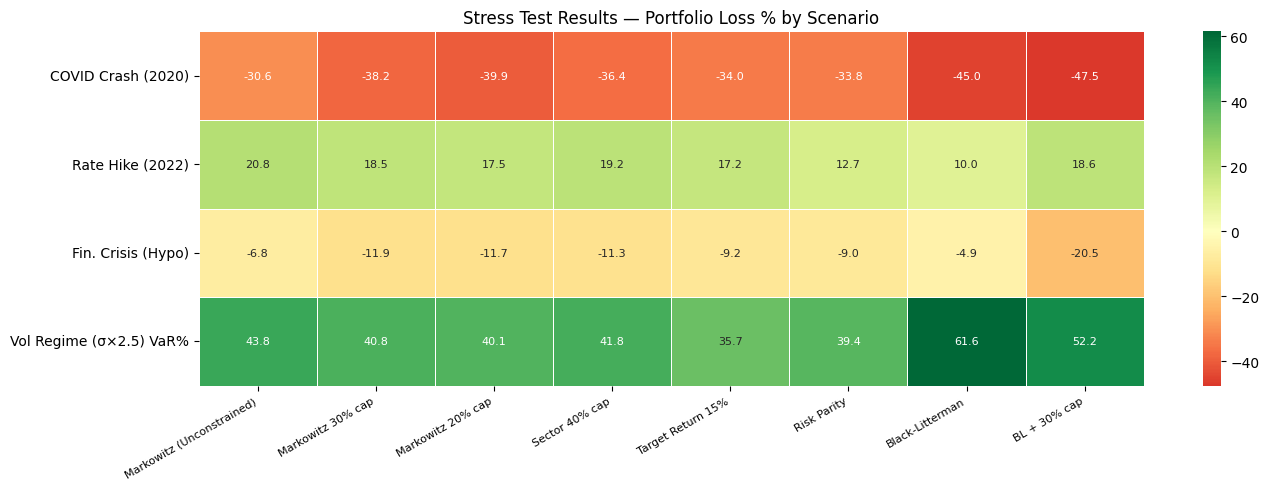

In [16]:
# │ CELL 13c — Historical Stress Test Summary Heatmap                      │
# └─────────────────────────────────────────────────────────────────────────┘
 
# Combine all scenario losses into one DataFrame
stress_rows = {}
if covid:  stress_rows["COVID Crash (2020)"]      = covid_port_loss
if rate:   stress_rows["Rate Hike (2022)"]         = rate_port_loss
stress_rows["Fin. Crisis (Hypo)"] = fin_losses
stress_rows["Vol Regime (σ×2.5) VaR%"] = {n: v["VaR 95%"] for n, v in vol_shock_results.items()}
 
stress_df = pd.DataFrame(stress_rows).T
stress_df = stress_df.astype(float)
 
plt.figure(figsize=(14, 5))
sns.heatmap(stress_df, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Stress Test Results — Portfolio Loss % by Scenario")
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.tight_layout(); plt.show()

── Maximum Drawdown ──
  Black-Litterman                   -23.66%
  BL + 30% cap                      -19.43%
  Risk Parity                       -18.17%
  Markowitz 30% cap                 -16.12%
  Markowitz 20% cap                 -15.89%
  Sector 40% cap                    -15.87%
  Markowitz (Unconstrained)         -15.07%
  Target Return 15%                 -14.69%


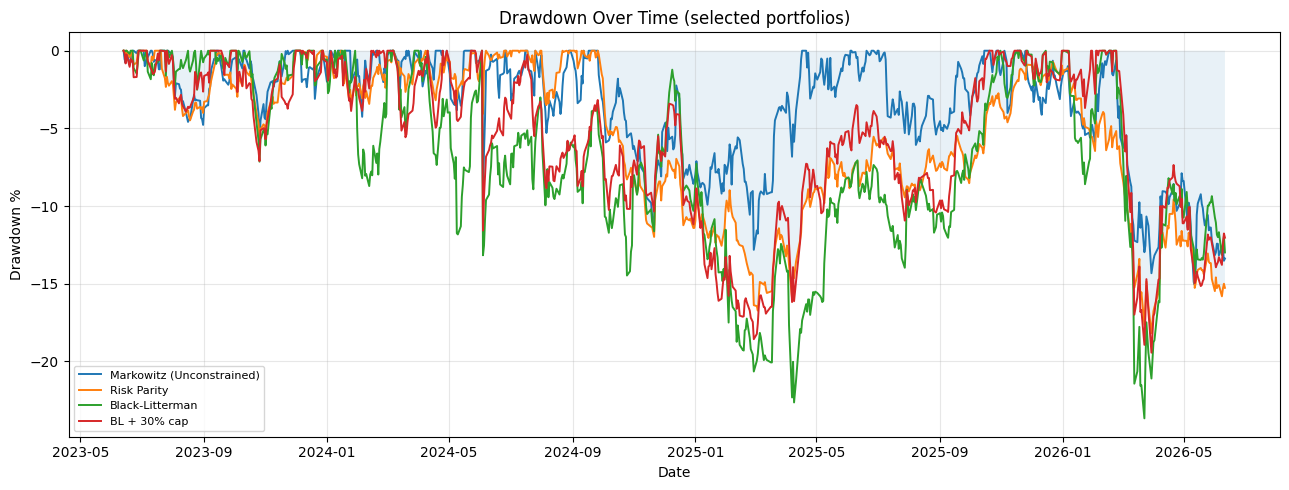

In [17]:
# │ CELL 14 — Maximum Drawdown                                              │
# │ Max peak-to-trough decline in cumulative returns.                      │
# │ Key metric for risk — tells you the worst loss an investor experienced.│
# └─────────────────────────────────────────────────────────────────────────┘
 
def max_drawdown(ret_series):
    cum   = (1 + ret_series).cumprod()
    peak  = cum.cummax()
    dd    = (cum - peak) / peak
    return dd.min()
 
mdd = {name: round(max_drawdown(port_returns[name]) * 100, 2)
       for name in port_names}
 
print("── Maximum Drawdown ──")
for name, dd in sorted(mdd.items(), key=lambda x: x[1]):
    print(f"  {name:<32} {dd:>7.2f}%")
 
# Drawdown over time plot
dd_series = {}
for name in port_names:
    cum  = (1 + port_returns[name]).cumprod()
    peak = cum.cummax()
    dd_series[name] = ((cum - peak) / peak) * 100
 
dd_df = pd.DataFrame(dd_series)
 
plt.figure(figsize=(13, 5))
for name in plot_ports:
    plt.plot(dd_df.index, dd_df[name], label=name, lw=1.4)
plt.fill_between(dd_df.index, dd_df["Risk Parity"], alpha=0.1)
plt.xlabel("Date"); plt.ylabel("Drawdown %")
plt.title("Drawdown Over Time (selected portfolios)")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [18]:
# PHASE 4 — PORTFOLIO COMPARISON DASHBOARD
# Goal: single table comparing all portfolios across every risk dimension
# =============================================================================
 
 
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 15 — VaR & CVaR for All Portfolios                                 │
# │ Historical (non-parametric) at 95% confidence.                        │
# └─────────────────────────────────────────────────────────────────────────┘
 
var_cvar = {}
for name in port_names:
    data     = port_returns[name].dropna().values
    var_95   = -np.percentile(data, 5)
    cvar_95  = -data[data <= -var_95].mean()
    var_cvar[name] = {"VaR 95% (daily)":  round(var_95 * 100, 3),
                      "CVaR 95% (daily)": round(cvar_95 * 100, 3)}
 
var_df = pd.DataFrame(var_cvar).T
print("── Daily VaR & CVaR (95%) ──")
print(var_df.to_string())

── Daily VaR & CVaR (95%) ──
                           VaR 95% (daily)  CVaR 95% (daily)
Markowitz (Unconstrained)            1.559             2.436
Markowitz 30% cap                    1.365             2.206
Markowitz 20% cap                    1.291             2.129
Sector 40% cap                       1.407             2.252
Target Return 15%                    1.199             1.778
Risk Parity                          1.186             1.708
Black-Litterman                      2.018             3.395
BL + 30% cap                         1.780             2.693


── Component VaR & Marginal VaR (95%, Parametric) ──
  Markowitz (Unconstrained)  |  Portfolio VaR = 29.203%
  Stock             Marg VaR%    Component%    Contrib%
  ----------------------------------------------------
  BHARTIARTL          32.027%      23.1055%       79.1%
  SBIN                22.535%       5.1023%       17.5%
  LT                  19.084%       0.9952%        3.4%
  TITAN               13.314%       0.0000%        0.0%
  ICICIBANK           13.837%       0.0000%        0.0%
  MARUTI              13.078%       0.0000%        0.0%
  AXISBANK            15.045%       0.0000%        0.0%
  RELIANCE            15.579%       0.0000%        0.0%
  KOTAKBANK           14.332%       0.0000%        0.0%
  HDFCBANK            12.460%       0.0000%        0.0%
  INFY                 9.962%       0.0000%        0.0%
  ASIANPAINT           8.830%       0.0000%        0.0%
  ITC                  8.491%       0.0000%        0.0%
  TCS                  8.476%       0.0000%        0

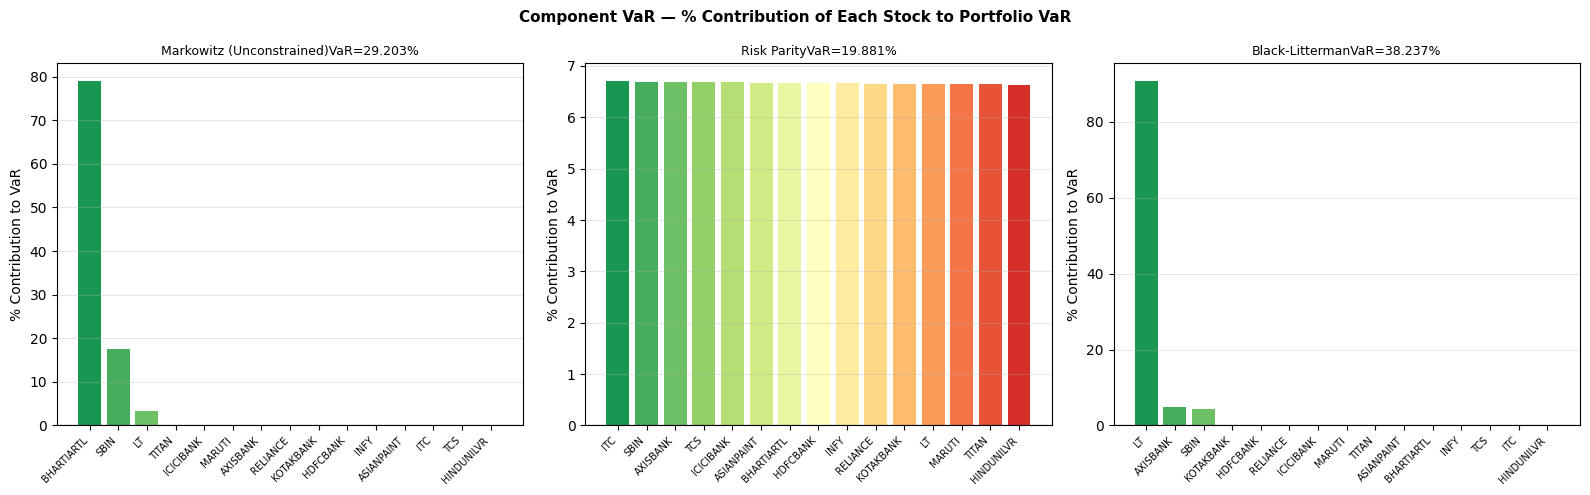

In [22]:
# │ CELL 15b — Component VaR & Marginal VaR                                │
# │                                                                         │
# │ Regular VaR tells you total portfolio risk.                            │
# │ Component VaR: how much does each stock CONTRIBUTE to total VaR?      │
# │ Marginal VaR:  if I add ₹1 more of stock i, how much does VaR change? │
# │                                                                         │
# │ Formula (parametric, normal):                                          │
# │   Portfolio VaR = z × σ_p  (z = 1.645 for 95%)                       │
# │   Marginal VaR_i = z × (Σw)_i / σ_p   (sensitivity to weight i)      │
# │   Component VaR_i = w_i × Marginal VaR_i                              │
# │   Check: Σ Component VaR_i = Portfolio VaR  (always true)             │
# └─────────────────────────────────────────────────────────────────────────┘
 
Z = norm.ppf(0.95)   # 1.645 for 95% confidence
 
print("── Component VaR & Marginal VaR (95%, Parametric) ──")
 
cvar_components = {}
 
for name, w in portfolios.items():
    sigma_p   = np.sqrt(w @ Sigma @ w)         # portfolio daily vol
    port_var  = Z * sigma_p                    # portfolio VaR (daily, decimal)
 
    # Marginal VaR: partial derivative of VaR w.r.t. each weight
    mvar = Z * (Sigma @ w) / sigma_p           # shape (n,)
 
    # Component VaR: how much each stock contributes
    cvar_comp = w * mvar                        # shape (n,)
 
    # Percentage contribution
    pct_contrib = cvar_comp / port_var * 100
 
    cvar_components[name] = {
        "Port VaR (daily %)": round(port_var * 100, 3),
        "components":         pd.Series(pct_contrib, index=short),
        "marginal":           pd.Series(mvar * 100,  index=short),
    }
 
# Print for key portfolios
for name in ["Markowitz (Unconstrained)", "Risk Parity", "Black-Litterman"]:
    info = cvar_components[name]
    print(f"  {name}  |  Portfolio VaR = {info['Port VaR (daily %)']:.3f}%")
    print(f"  {'Stock':<16} {'Marg VaR%':>10}  {'Component%':>12}  {'Contrib%':>10}")
    print(f"  {'-'*52}")
    comp = info["components"].sort_values(ascending=False)
    marg = info["marginal"]
    for stock in comp.index:
        print(f"  {stock:<16} {marg[stock]:>9.3f}%  {comp[stock]/100*info['Port VaR (daily %)']:>11.4f}%  {comp[stock]:>9.1f}%")
    print(f"  {'TOTAL':<16} {'':>10}  {info['Port VaR (daily %)']:>11.3f}%  {'100.0':>9}%")
 
# Visual: Component VaR contribution stacked bar
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
focus = ["Markowitz (Unconstrained)", "Risk Parity", "Black-Litterman"]
 
for ax, name in zip(axes, focus):
    comp = cvar_components[name]["components"].sort_values(ascending=False)
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(comp)))
    bars = ax.bar(comp.index, comp.values, color=colors)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{name}VaR={cvar_components[name]['Port VaR (daily %)']:.3f}%",
                 fontsize=9)
    ax.set_ylabel("% Contribution to VaR")
    ax.set_xticklabels(comp.index, rotation=45, ha="right", fontsize=7)
    ax.grid(axis="y", alpha=0.3)
 
plt.suptitle("Component VaR — % Contribution of Each Stock to Portfolio VaR",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

In [31]:
# │ CELL 16 — Full Comparison Dashboard                                     │
# │ Every metric in one table.                                             │
# └─────────────────────────────────────────────────────────────────────────┘
 
dashboard = []
for name, w in portfolios.items():
    ann_ret  = w @ mu
    ann_risk = np.sqrt(w @ Sigma @ w)
    sharpe   = (ann_ret - RF) / ann_risk
    hhi      = np.sum(w**2)
    tv       = terminal_values[name]
 
    dashboard.append({
        "Portfolio":         name,
        "Return %":          round(ann_ret * 100, 1),
        "Risk %":            round(ann_risk * 100, 1),
        "Sharpe":            round(sharpe, 2),
        "HHI":               round(hhi, 2),
        "VaR 95%":           var_cvar[name]["VaR 95% (daily)"],
        "CVaR 95%":          var_cvar[name]["CVaR 95% (daily)"],
        "Max DD %":          mdd[name],
        "P(Loss) %":         round((tv < INITIAL).mean() * 100, 1),
        "E[Wealth] ₹L":      round(np.mean(tv) / 1e5, 1),
        "Crash Loss %":      stress_df.loc["COVID Crash (2020)", name] if "COVID Crash (2020)" in stress_df.index else None,
        "Rate Shock %":      stress_df.loc["Rate Hike (2022)", name]   if "Rate Hike (2022)"   in stress_df.index else None,
        "Kupiec":  next((r["Verdict"] for r in kupiec_results if r["Portfolio"] == name), "N/A"),

    })
 
dash_df = pd.DataFrame(dashboard)
 
print("\n" + "="*110)
print(dash_df.to_string(index=False))
print("="*110)
 


                Portfolio  Return %  Risk %  Sharpe  HHI  VaR 95%  CVaR 95%  Max DD %  P(Loss) %  E[Wealth] ₹L  Crash Loss %  Rate Shock %                Kupiec
Markowitz (Unconstrained)      24.6    17.8    1.02 0.57    1.559     2.436    -15.07        9.5          12.8        -30.64         20.80     ✓ PASS (model ok)
        Markowitz 30% cap      20.0    15.8    0.85 0.23    1.365     2.206    -16.12       11.6          12.2        -38.21         18.50 ✗ FAIL (misspecified)
        Markowitz 20% cap      17.9    15.1    0.75 0.18    1.291     2.129    -15.89       13.7          12.0        -39.94         17.46 ✗ FAIL (misspecified)
           Sector 40% cap      21.5    16.3    0.92 0.29    1.407     2.252    -15.87       11.4          12.4        -36.44         19.23 ✗ FAIL (misspecified)
        Target Return 15%      15.0    13.2    0.65 0.18    1.199     1.778    -14.69       14.3          11.6        -33.99         17.23 ✗ FAIL (misspecified)
              Risk Parity       4

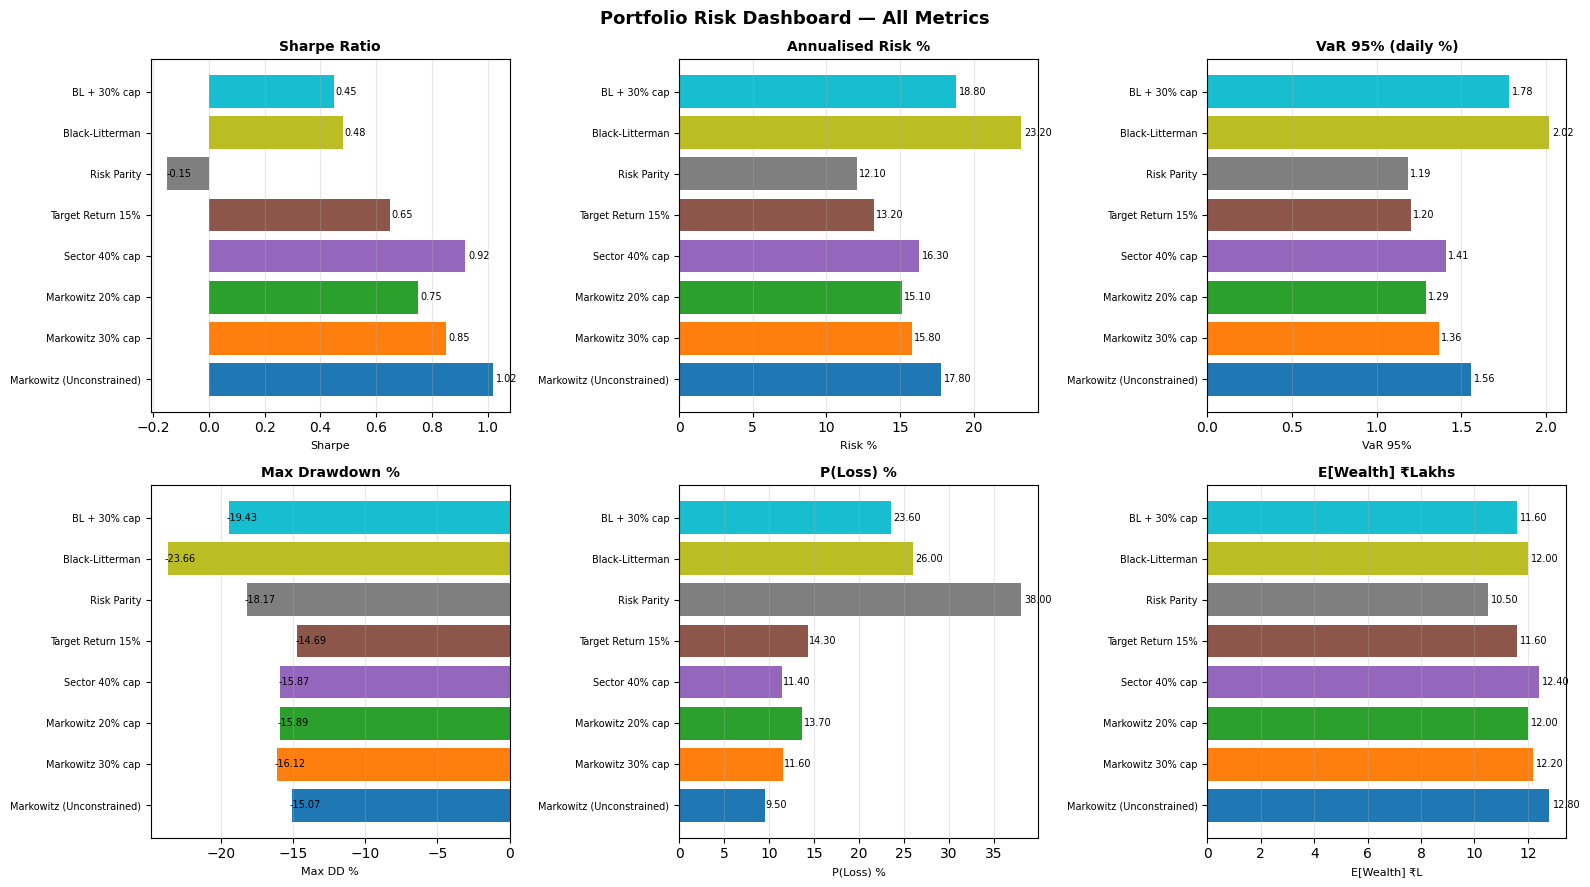

In [25]:
# │ CELL 17 — Visual Dashboard                                              │
# │ 6-panel summary chart across key metrics.                              │
# └─────────────────────────────────────────────────────────────────────────┘
 
metrics_to_plot = {
    "Sharpe Ratio":        "Sharpe",
    "Annualised Risk %":   "Risk %",
    "VaR 95% (daily %)":   "VaR 95%",
    "Max Drawdown %":      "Max DD %",
    "P(Loss) %":           "P(Loss) %",
    "E[Wealth] ₹Lakhs":    "E[Wealth] ₹L",
}
 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(port_names)))
 
for i, (title, col) in enumerate(metrics_to_plot.items()):
    ax  = axes[i]
    vals = dash_df[col].astype(float)
    bars = ax.barh(dash_df["Portfolio"], vals, color=colors)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(col, fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="x", alpha=0.3)
    # Annotate values
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=7)
 
plt.suptitle("Portfolio Risk Dashboard — All Metrics", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

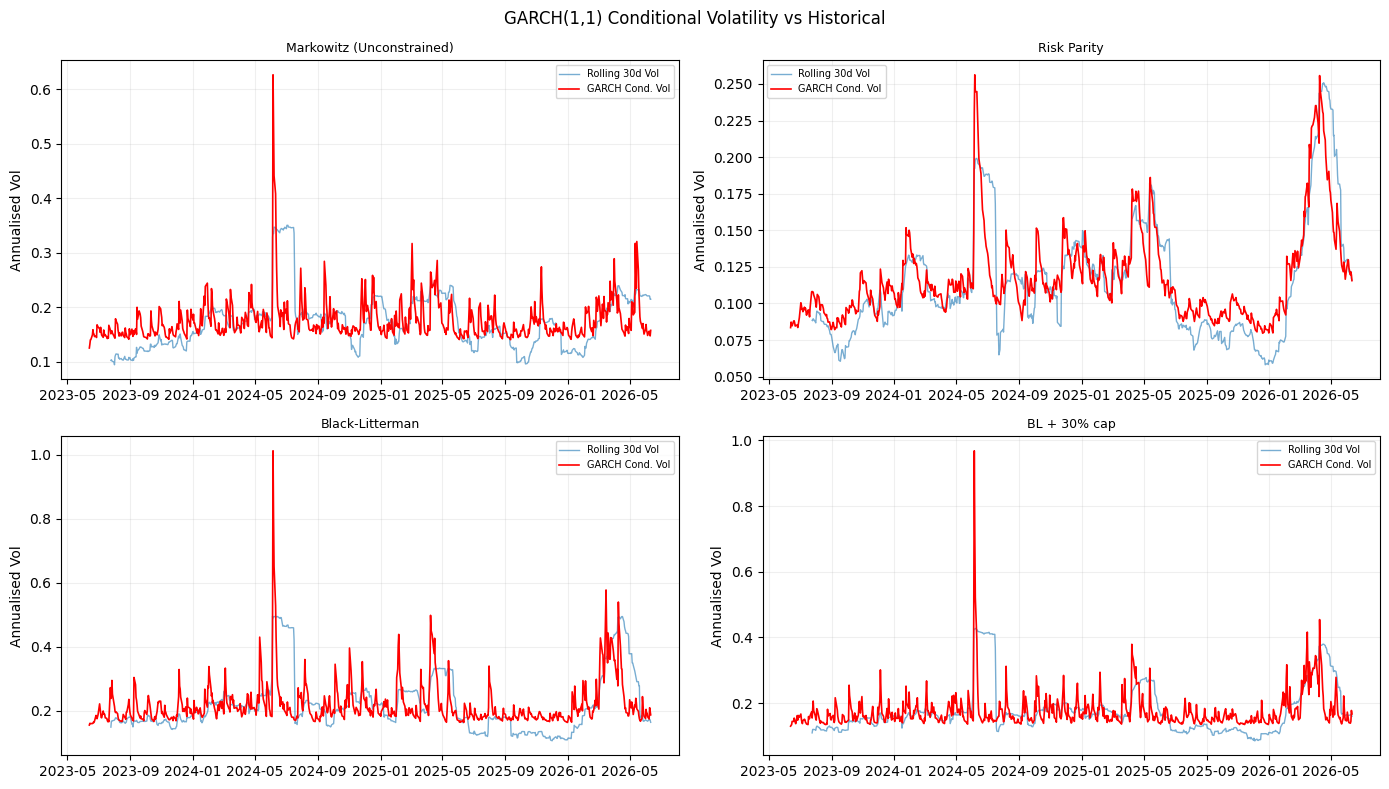


── GARCH 30-Day Volatility Forecast ──
  Portfolio                          Day1 Vol   Day15 Vol   Day30 Vol
--------------------------------------------------------------------
  Markowitz (Unconstrained)            15.01%      17.92%      17.99%
  Risk Parity                          11.23%      11.66%      11.94%
  Black-Litterman                      19.96%      22.86%      23.02%
  BL + 30% cap                         15.34%      18.18%      18.22%


In [26]:
# PHASE 5 — GARCH VOLATILITY FORECASTING
# Goal: forward-looking volatility estimate using GARCH(1,1)
# =============================================================================
 
 
# ┌─────────────────────────────────────────────────────────────────────────┐
# │ CELL 18 — GARCH(1,1) on Selected Portfolios                            │
# │ GARCH captures volatility clustering: big moves → more big moves.     │
# │ Fit GARCH(1,1) to daily returns, forecast next 30 days.               │
# └─────────────────────────────────────────────────────────────────────────┘
 
try:
    from arch import arch_model
 
    garch_ports = ["Markowitz (Unconstrained)", "Risk Parity",
                   "Black-Litterman", "BL + 30% cap"]
 
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
 
    garch_forecasts = {}
 
    for i, name in enumerate(garch_ports):
        ax   = axes[i]
        data = port_returns[name].dropna() * 100   # GARCH works better in % scale
 
        model   = arch_model(data, vol="Garch", p=1, q=1, dist="normal")
        result  = model.fit(disp="off")
        forecast = result.forecast(horizon=30)
        fcast_vol = np.sqrt(forecast.variance.values[-1]) / 100   # back to decimal
 
        garch_forecasts[name] = fcast_vol
 
        # Historical rolling vol
        hist_vol = data.rolling(30).std().dropna() / 100 * np.sqrt(252)
        cond_vol = result.conditional_volatility / 100 * np.sqrt(252)
 
        ax.plot(hist_vol.index, hist_vol, label="Rolling 30d Vol", alpha=0.6, lw=1)
        ax.plot(cond_vol.index, cond_vol, label="GARCH Cond. Vol",
                color="red", lw=1.2)
        ax.set_title(name, fontsize=9)
        ax.set_ylabel("Annualised Vol"); ax.legend(fontsize=7); ax.grid(alpha=0.2)
 
    plt.suptitle("GARCH(1,1) Conditional Volatility vs Historical", fontsize=12)
    plt.tight_layout(); plt.show()
 
    # 30-day forecast summary
    print("\n── GARCH 30-Day Volatility Forecast ──")
    print(f"  {'Portfolio':<32} {'Day1 Vol':>10}  {'Day15 Vol':>10}  {'Day30 Vol':>10}")
    print("-"*68)
    for name, fv in garch_forecasts.items():
        print(f"  {name:<32} {fv[0]*np.sqrt(252)*100:>9.2f}%  "
              f"{fv[14]*np.sqrt(252)*100:>9.2f}%  "
              f"{fv[29]*np.sqrt(252)*100:>9.2f}%")
 
except ImportError:
    print("arch package not installed. Run: pip install arch")
    print("Skipping GARCH section.")

In [28]:
# │ CELL 19 — GARCH VaR vs Historical VaR                                  │
# │ Use GARCH conditional volatility to compute forward-looking VaR.      │
# │ Compare to historical VaR — shows if risk is currently above/below     │
# │ long-run average.                                                      │
# └─────────────────────────────────────────────────────────────────────────┘
 
try:
    print("\n── GARCH VaR vs Historical VaR (95%, daily) ──")
    print(f"  {'Portfolio':<32} {'Hist VaR':>10}  {'GARCH VaR':>10}  {'Diff':>8}")
    print("-"*65)
 
    for name in garch_ports:
        hist_v  = var_cvar[name]["VaR 95% (daily)"]
        if name in garch_forecasts:
            garch_v = garch_forecasts[name][0] * norm.ppf(0.95) * 100
            diff    = garch_v - hist_v
            flag    = "↑ higher risk" if diff > 0.1 else ("↓ lower risk" if diff < -0.1 else "≈ stable")
            print(f"  {name:<32} {hist_v:>9.3f}%  {garch_v:>9.3f}%  {flag}")
 
except Exception as e:
    print(f"Skipped: {e}")


── GARCH VaR vs Historical VaR (95%, daily) ──
  Portfolio                          Hist VaR   GARCH VaR      Diff
-----------------------------------------------------------------
  Markowitz (Unconstrained)            1.559%      1.556%  ≈ stable
  Risk Parity                          1.186%      1.163%  ≈ stable
  Black-Litterman                      2.018%      2.069%  ≈ stable
  BL + 30% cap                         1.780%      1.589%  ↓ lower risk


In [29]:
# │ CELL 20 — Kupiec VaR Backtesting                                        │
# │                                                                         │
# │ Idea: if VaR(95%) is correct, actual daily losses should exceed it     │
# │ exactly 5% of the time (breaches). Too many = VaR underestimates risk. │
# │ Too few = VaR is over-conservative.                                    │
# │                                                                         │
# │ Kupiec POF test (Proportion of Failures):                              │
# │   H0: breach rate = 5%  (VaR model is correct)                        │
# │   LR = -2 ln[ p^x (1-p)^(T-x) / α^x (1-α)^(T-x) ]  ~ χ²(1)         │
# │   where x = actual breaches, T = total days, α = 0.05                 │
# │   Reject H0 (model is bad) if LR > 3.841 (χ² critical at 95%)        │
# └─────────────────────────────────────────────────────────────────────────┘
 
from scipy.stats import chi2
 
def kupiec_test(returns_series, confidence=0.95):
    """
    Run Kupiec POF backtest on a return series.
    Returns dict with breach counts, LR statistic, p-value, and verdict.
    """
    alpha   = 1 - confidence
    T       = len(returns_series)
 
    # Compute rolling VaR: for each day t, VaR is estimated on all days before t
    # Use expanding window so we don't look ahead
    var_series = returns_series.expanding(min_periods=60).quantile(alpha)
 
    # Breach: actual return < -VaR on that day
    breaches   = (returns_series < var_series).sum()
    breach_rate = breaches / T
 
    # Kupiec LR statistic
    # Avoid log(0) edge cases
    if breaches == 0 or breaches == T:
        return {"T": T, "Expected": round(alpha*T, 1), "Actual": breaches,
                "Breach Rate %": 0.0, "LR Stat": np.nan,
                "p-value": np.nan, "Verdict": "insufficient data"}
 
    LR = -2 * (
        breaches     * np.log(alpha / breach_rate) +
        (T - breaches) * np.log((1 - alpha) / (1 - breach_rate))
    )
    p_val   = 1 - chi2.cdf(LR, df=1)
    verdict = "✓ PASS (model ok)" if p_val > 0.05 else "✗ FAIL (misspecified)"
 
    return {
        "T":             T,
        "Expected":      round(alpha * T, 1),
        "Actual":        int(breaches),
        "Breach Rate %": round(breach_rate * 100, 2),
        "LR Stat":       round(LR, 4),
        "p-value":       round(p_val, 4),
        "Verdict":       verdict,
    }
 
# Run for all portfolios
print("── Kupiec POF Backtest (VaR 95%) ──")
print(f"  H0: breach rate = 5%  |  Reject if p-value < 0.05\n")
print(f"  {'Portfolio':<32} {'T':>5}  {'Exp':>6}  {'Act':>5}  {'Rate%':>7}  {'LR':>7}  {'p-val':>7}  Verdict")
print("-"*105)
 
kupiec_results = []
for name in port_names:
    res = kupiec_test(port_returns[name].dropna())
    res["Portfolio"] = name
    kupiec_results.append(res)
    print(f"  {name:<32} {res['T']:>5}  {res['Expected']:>6}  {res['Actual']:>5}  "
          f"{res['Breach Rate %']:>6.2f}%  {res['LR Stat']:>7.4f}  "
          f"{res['p-value']:>7.4f}  {res['Verdict']}")
 
print("-"*105)
print("  LR critical value = 3.841 (χ²(1) at 95%)")
 

── Kupiec POF Backtest (VaR 95%) ──
  H0: breach rate = 5%  |  Reject if p-value < 0.05

  Portfolio                            T     Exp    Act    Rate%       LR    p-val  Verdict
---------------------------------------------------------------------------------------------------------
  Markowitz (Unconstrained)          741    37.1     49    6.61%   3.7001   0.0544  ✓ PASS (model ok)
  Markowitz 30% cap                  741    37.1     56    7.56%   8.8801   0.0029  ✗ FAIL (misspecified)
  Markowitz 20% cap                  741    37.1     54    7.29%   7.1967   0.0073  ✗ FAIL (misspecified)
  Sector 40% cap                     741    37.1     54    7.29%   7.1967   0.0073  ✗ FAIL (misspecified)
  Target Return 15%                  741    37.1     55    7.42%   8.0188   0.0046  ✗ FAIL (misspecified)
  Risk Parity                        741    37.1     50    6.75%   4.3152   0.0378  ✗ FAIL (misspecified)
  Black-Litterman                    741    37.1     47    6.34%   2.6020   0.106

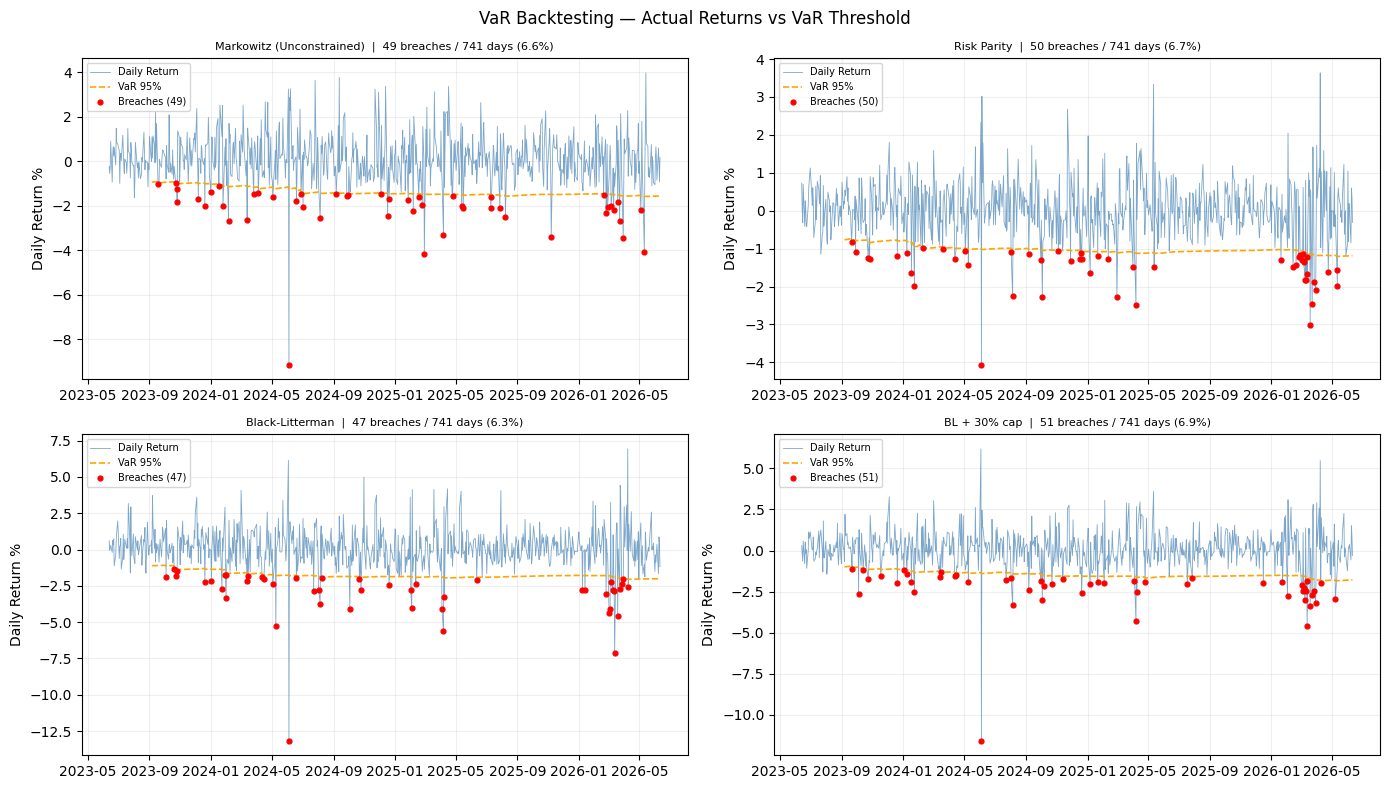

In [30]:
# │ CELL 21 — Breach Visualisation                                          │
# │ Plot actual returns vs rolling VaR — breaches shown as red dots.      │
# └─────────────────────────────────────────────────────────────────────────┘
 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
 
for i, name in enumerate(plot_ports):
    ax   = axes[i]
    data = port_returns[name].dropna()
    var  = data.expanding(min_periods=60).quantile(0.05)   # rolling VaR threshold
 
    breaches = data < var
 
    ax.plot(data.index, data * 100,
            color="steelblue", lw=0.6, alpha=0.7, label="Daily Return")
    ax.plot(data.index, var * 100,
            color="orange", lw=1.2, linestyle="--", label="VaR 95%")
    ax.scatter(data.index[breaches], data[breaches] * 100,
               color="red", s=12, zorder=5, label=f"Breaches ({breaches.sum()})")
 
    ax.set_title(f"{name}  |  {breaches.sum()} breaches / {len(data)} days "
                 f"({breaches.mean()*100:.1f}%)", fontsize=8)
    ax.set_ylabel("Daily Return %"); ax.legend(fontsize=7); ax.grid(alpha=0.2)
 
plt.suptitle("VaR Backtesting — Actual Returns vs VaR Threshold", fontsize=12)
plt.tight_layout(); plt.show()